In [ ]:
import os
import h5py
import numpy as np
import cv2
import random
from shutil import copyfile

h5_dir = "/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/BraTS2020_training_data"
output_base = "data"

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15 


modality_channel = 3

binary_mask = True


for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_base, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, 'masks'), exist_ok=True)

h5_files = []
for root, dirs, files in os.walk(h5_dir):
    for file in files:
        if file.endswith(".h5"):
            h5_files.append(os.path.join(root, file))

print(f"🔍 Found {len(h5_files)} .h5 files")

if len(h5_files) == 0:
    print("No .h5 files found! Check folder structure.")
    exit()

random.shuffle(h5_files)

num_files = len(h5_files)
num_train = int(num_files * train_ratio)
num_val = int(num_files * val_ratio)
num_test = num_files - num_train - num_val

train_files = h5_files[:num_train]
val_files = h5_files[num_train:num_train+num_val]
test_files = h5_files[num_train+num_val:]

split_dict = {
    'train': train_files,
    'val': val_files,
    'test': test_files
}

counter = 0

for split_name, file_list in split_dict.items():
    print(f"\nProcessing {split_name} set ({len(file_list)} files)...")

    for file_path in file_list:
        try:
            with h5py.File(file_path, 'r') as f:
                image = f['image']  
                mask = f['mask']    

               
                img_slice = image[:, :, modality_channel]

               
                img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)
                img_slice = (img_slice * 255).astype(np.uint8)

              
                if binary_mask:
                  
                    mask_slice = (np.sum(mask, axis=2) > 0).astype(np.uint8) * 255
                else:
                 
                    mask_slice = mask.astype(np.uint8)

               
                if np.sum(mask_slice) == 0:
                    continue

                
                img_name = f"img_{counter}.png"
                mask_name = f"mask_{counter}.png"

                cv2.imwrite(os.path.join(output_base, split_name, 'images', img_name), img_slice)
                cv2.imwrite(os.path.join(output_base, split_name, 'masks', mask_name), mask_slice)

                counter += 1

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

print("\n Conversion complete!")
print(f"Total images saved: {counter}")

🔍 Found 57195 .h5 files

Processing train set (40036 files)...

Processing val set (8579 files)...

Processing test set (8580 files)...

✅ Conversion complete!
Total images saved: 24422


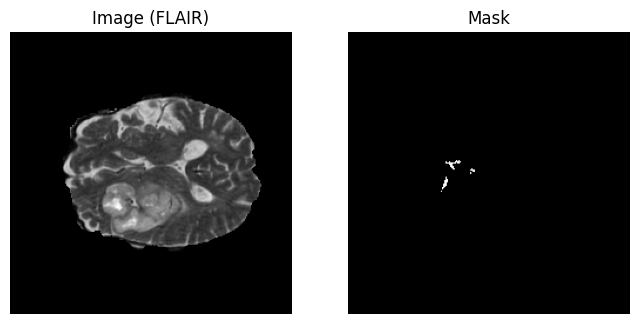

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


dataset_dir = "/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data"
splits = ['train', 'val', 'test']

img_path = os.path.join(dataset_dir, 'train', 'images', os.listdir(os.path.join(dataset_dir, 'train', 'images'))[0])
mask_path = os.path.join(dataset_dir, 'train', 'masks', os.listdir(os.path.join(dataset_dir, 'train', 'masks'))[0])

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title('Image (FLAIR)')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Mask')
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

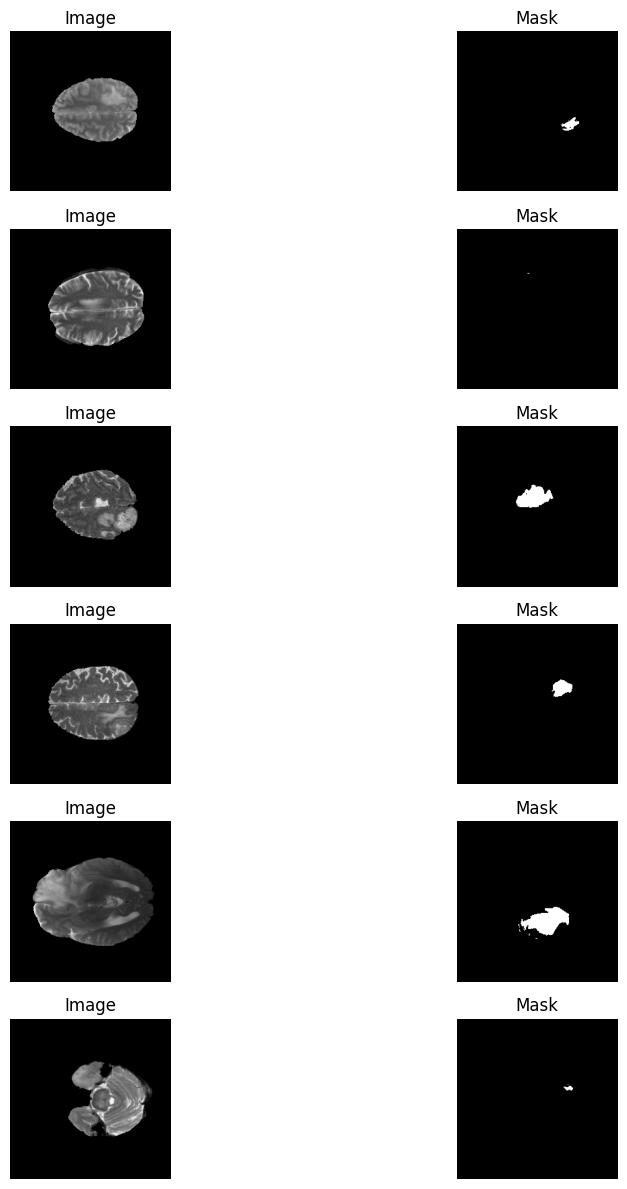

In [ ]:
def visualize_random_samples(images_dir, masks_dir, num_samples=5):
    imgs = os.listdir(images_dir)
    masks = os.listdir(masks_dir)
    idxs = np.random.choice(len(imgs), num_samples, replace=False)
    
    plt.figure(figsize=(12, num_samples*2))
    for i, idx in enumerate(idxs):
        img = cv2.imread(os.path.join(images_dir, imgs[idx]), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(masks_dir, masks[idx]), cv2.IMREAD_GRAYSCALE)
        
        plt.subplot(num_samples, 2, 2*i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title('Image')
        
        plt.subplot(num_samples, 2, 2*i+2)
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        plt.title('Mask')
    plt.tight_layout()
    plt.show()


visualize_random_samples("/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data/train/images", "/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data/train/masks", num_samples=6)

In [7]:
import glob

def compute_mask_stats(masks_dir):
    mask_files = glob.glob(os.path.join(masks_dir, "*.png"))
    total_pixels = 0
    tumor_pixels = 0
    
    for mfile in mask_files:
        mask = cv2.imread(mfile, cv2.IMREAD_GRAYSCALE)
        total_pixels += mask.size
        tumor_pixels += np.sum(mask > 0)
    
    print("Total pixels:", total_pixels)
    print("Tumor pixels:", tumor_pixels)
    print("Background pixels:", total_pixels - tumor_pixels)
    print("Tumor fraction: {:.4f}".format(tumor_pixels / total_pixels))

compute_mask_stats("/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data/train/masks")

Total pixels: 980697600
Tumor pixels: 25632542
Background pixels: 955065058
Tumor fraction: 0.0261


Class 0 fraction: 0.9739
Class 1 fraction: 0.0261


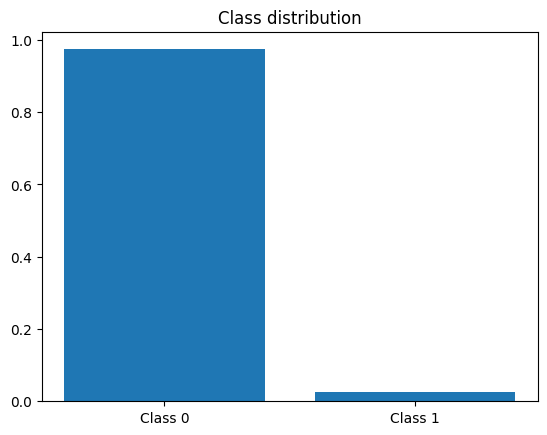

In [ ]:
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def multi_class_distribution(masks_dir, num_classes=3):
    mask_files = glob.glob(os.path.join(masks_dir, "*.png"))
    class_counts = np.zeros(num_classes)
    
    for mfile in mask_files:
        mask = cv2.imread(mfile, cv2.IMREAD_GRAYSCALE)  
        
        # Count pixels per class
        # If binary masks (0=background, 255=tumor), treat as class 1 vs 0
        # If multi-class, you need separate channels; here we assume 1 channel (binary)
        # We'll just count tumor vs background
        class_counts[0] += np.sum(mask == 0)      # background
        class_counts[1] += np.sum(mask > 0)       # tumor
        # class_counts[2] stays 0 (optional)
    
  
    class_fraction = class_counts / np.sum(class_counts)
    
    for i, frac in enumerate(class_fraction):
        print(f"Class {i} fraction: {frac:.4f}")
    
   
    plt.bar([f'Class {i}' for i in range(num_classes)], class_fraction)
    plt.title("Class distribution")
    plt.show()

multi_class_distribution("/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data/train/masks", num_classes=2)

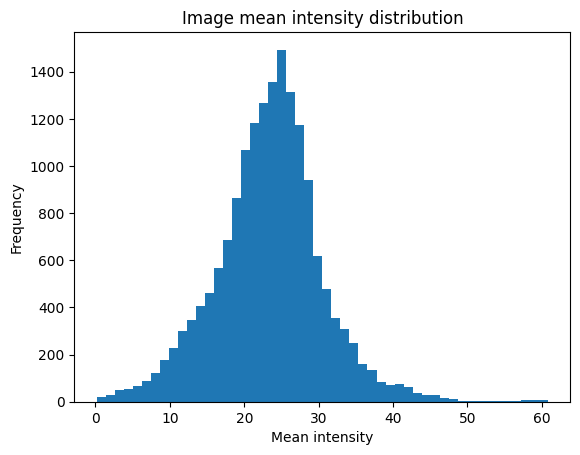

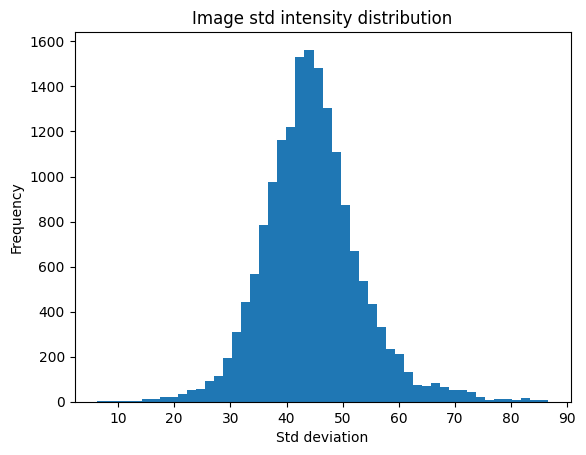

In [11]:
def image_intensity_stats(images_dir):
    imgs = glob.glob(os.path.join(images_dir, "*.png"))
    means, stds = [], []
    for imf in imgs:
        im = cv2.imread(imf, cv2.IMREAD_GRAYSCALE)
        means.append(np.mean(im))
        stds.append(np.std(im))
    
    plt.hist(means, bins=50)
    plt.title("Image mean intensity distribution")
    plt.xlabel("Mean intensity")
    plt.ylabel("Frequency")
    plt.show()
    
    plt.hist(stds, bins=50)
    plt.title("Image std intensity distribution")
    plt.xlabel("Std deviation")
    plt.ylabel("Frequency")
    plt.show()

image_intensity_stats("/home/predator/Desktop/college_project/Automatic-Brain-Tumor-Segmentation-from-MRI-Images-using-U-Net/data/train/images")